In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from zmq import SCATTER

In [3]:
df=pd.read_csv("glass.data")
df.head()

,id,Rl,Na,Mg,Al,Si,K,Ca,Ba,Fe,target
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [4]:
df=df.drop(columns=['id'])
df.head()

,Rl,Na,Mg,Al,Si,K,Ca,Ba,Fe,target
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [5]:
df.describe()

,Rl,Na,Mg,Al,Si,K,Ca,Ba,Fe,target
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [6]:
df.isnull().sum()

Rl        0
Na        0
Mg        0
Al        0
Si        0
K         0
Ca        0
Ba        0
Fe        0
target    0
dtype: int64

In [7]:
print(df['target'].unique())
print(len(df['target'].unique()))

[1 2 3 5 6 7]
6


In [8]:
df.value_counts("target")

target
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

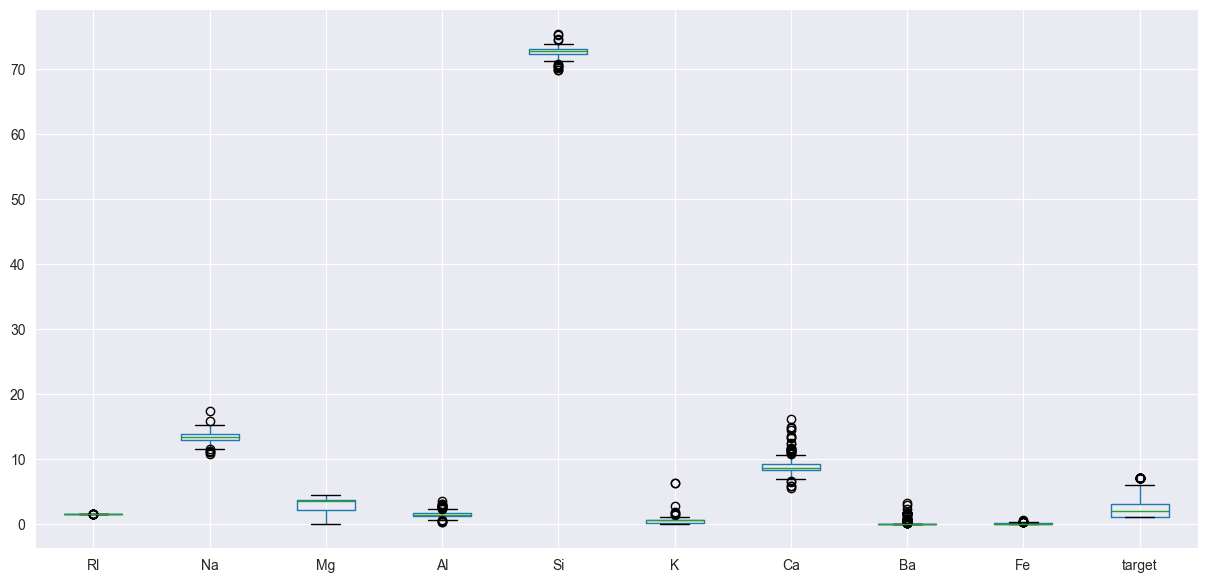

In [9]:
fig = plt.figure(figsize=(15, 7))
df.boxplot()
plt.show()

#податоците на тој атрибут немаат многу варијабилност, сите се „собрани“ околу средината.

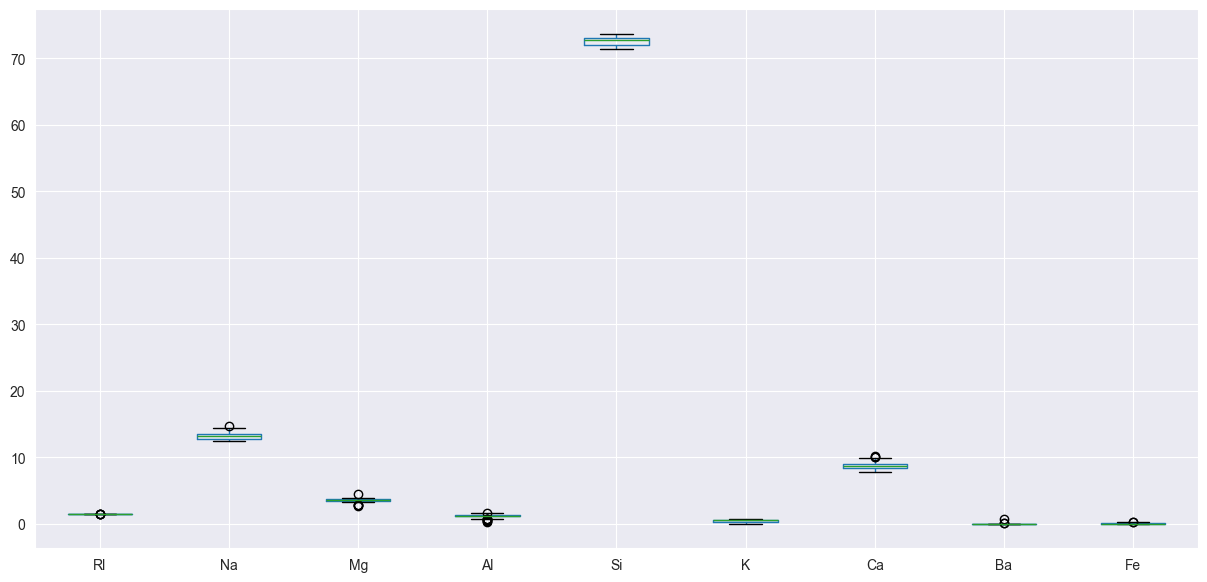

In [10]:
fig = plt.figure(figsize=(15, 7))
df[df.target==1].drop(['target'], axis=1).boxplot()
plt.show()


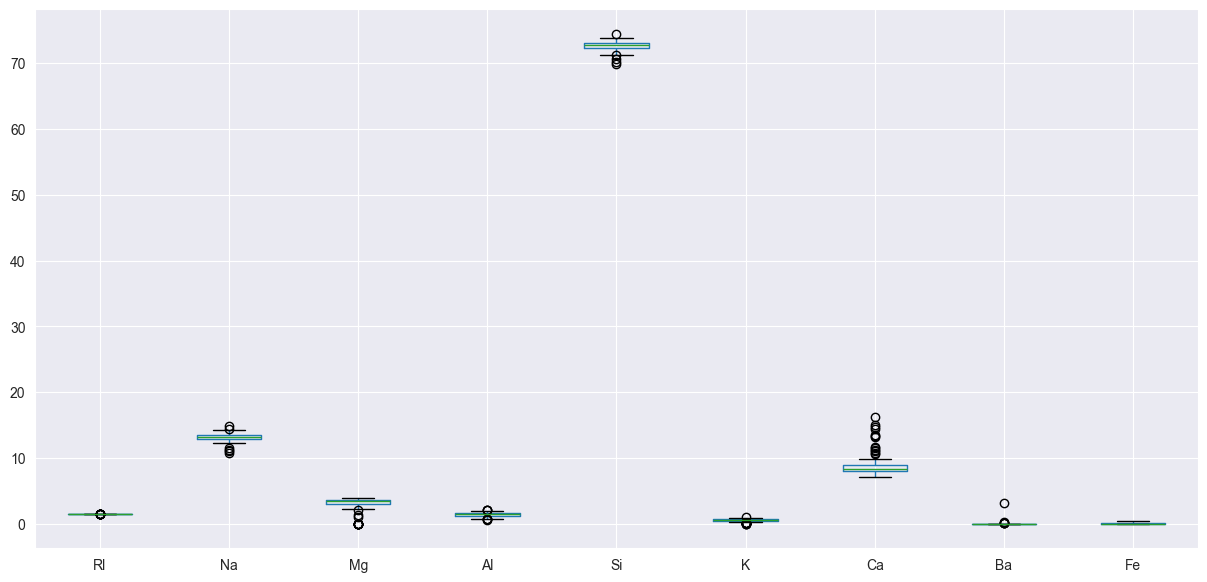

In [11]:
fig = plt.figure(figsize=(15, 7))
df[df.target==2].drop(['target'], axis=1).boxplot()
plt.show()


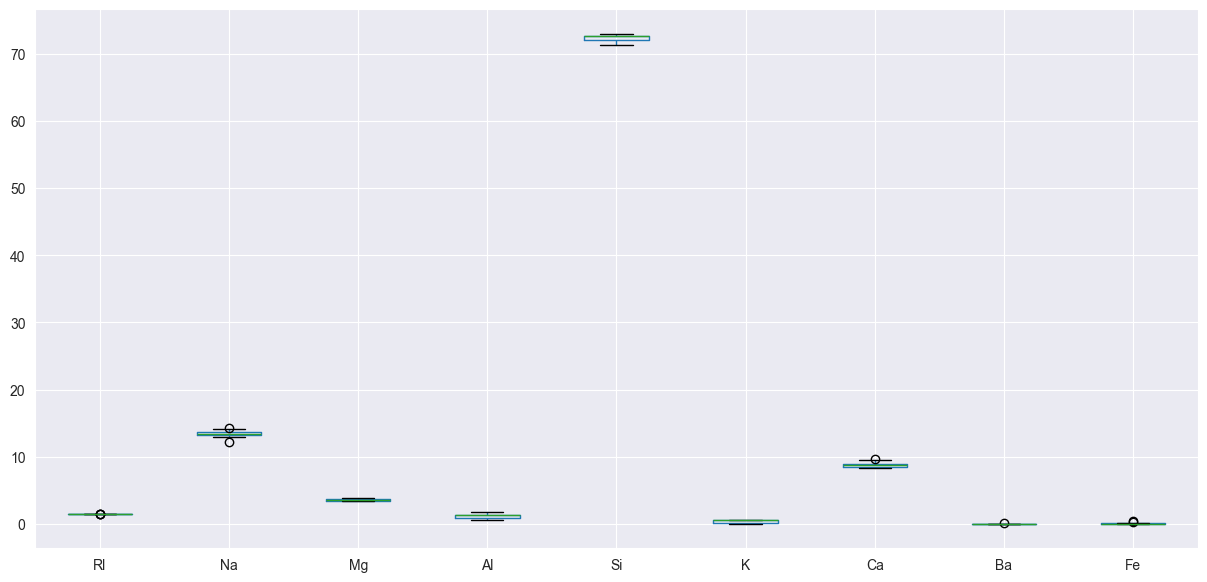

In [12]:
fig = plt.figure(figsize=(15, 7))
df[df.target==3].drop(['target'], axis=1).boxplot()
plt.show()


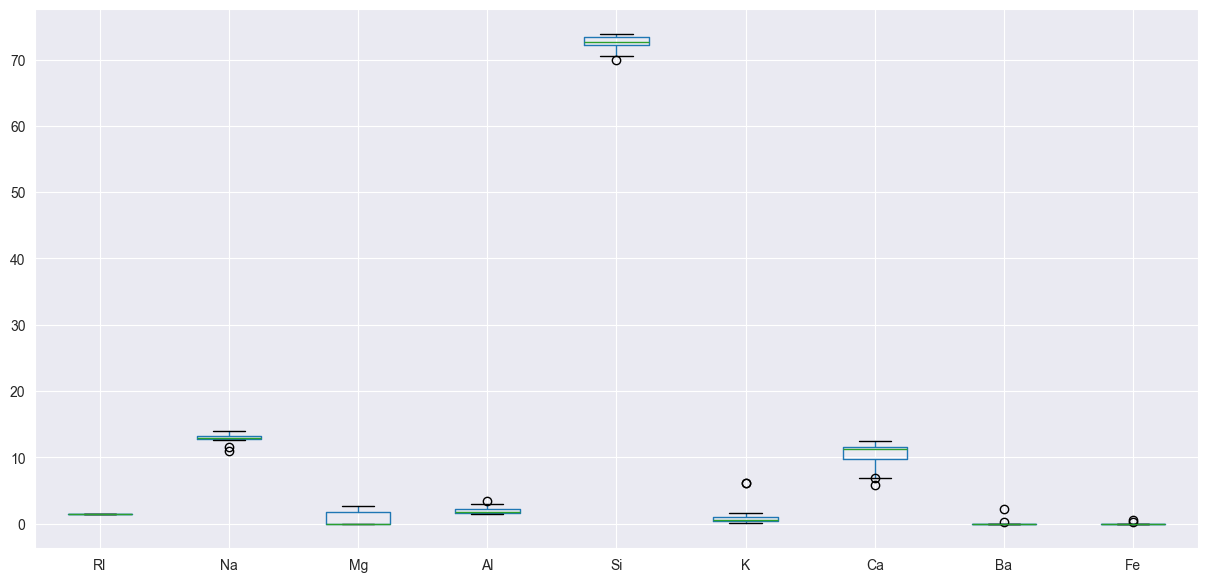

In [13]:
fig = plt.figure(figsize=(15, 7))
df[df.target==5].drop(['target'], axis=1).boxplot()
plt.show()


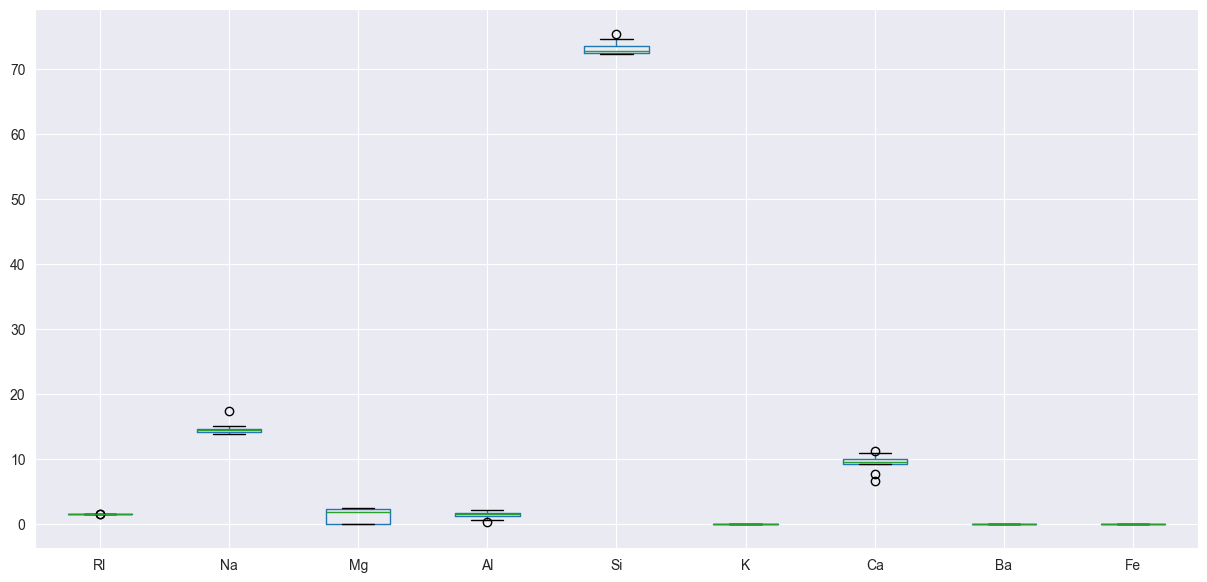

In [14]:
fig = plt.figure(figsize=(15, 7))
df[df.target==6].drop(['target'], axis=1).boxplot()
plt.show()


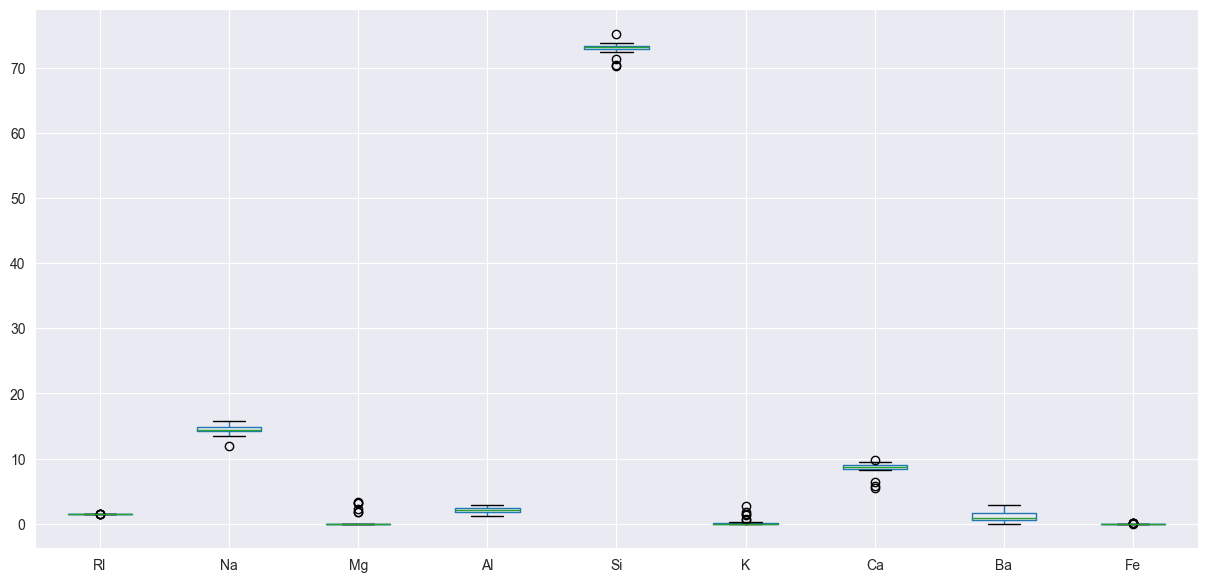

In [15]:
fig = plt.figure(figsize=(15, 7))
df[df.target==7].drop(['target'], axis=1).boxplot()
plt.show()


In [16]:
df.shape[1] - 1

9

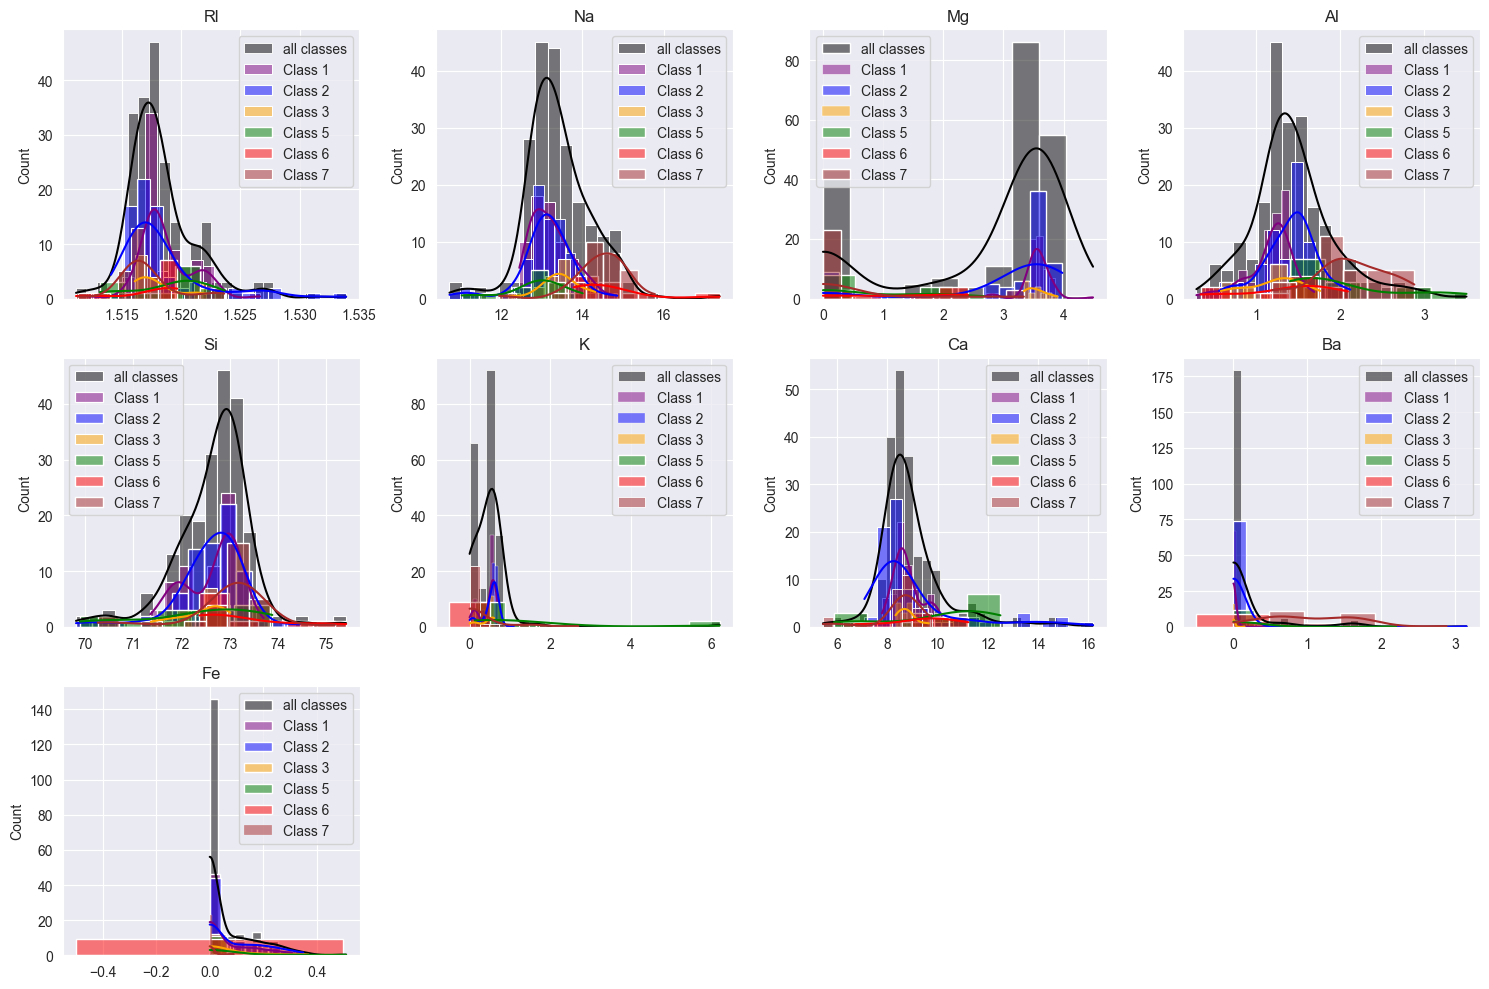

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Предпоставка: df е твојот DataFrame со Glass dataset
# последната колона е класата
X = df.iloc[:, :-1].values      # сите атрибути
y = df.iloc[:, -1].values       # target колона
feature_names = df.columns[:-1] # имиња на атрибутите
target_names = sorted(df.iloc[:, -1].unique()) # уникатни вредности на класата
number_of_features = X.shape[1]
number_of_classes = len(target_names)

colors = ['purple','blue','orange','green','red','brown','pink'] # повеќе бои ако имаш повеќе класи

fig = plt.figure(figsize=(15, 10))
for feature in range(number_of_features):
    ax = plt.subplot(3, 4, feature+1)  # 3x4 grid за 10 атрибути
    plt.title(feature_names[feature])
    # хистограм за сите примероци
    sns.histplot(X[:,feature], color='black', label='all classes', kde=True, stat="count")
    # хистограм по класа
    for idx, Class in enumerate(target_names):
        sns.histplot(X[y == Class, feature], color=colors[idx], label=f'Class {Class}', kde=True, stat="count")
    plt.legend()

plt.tight_layout()
plt.show()

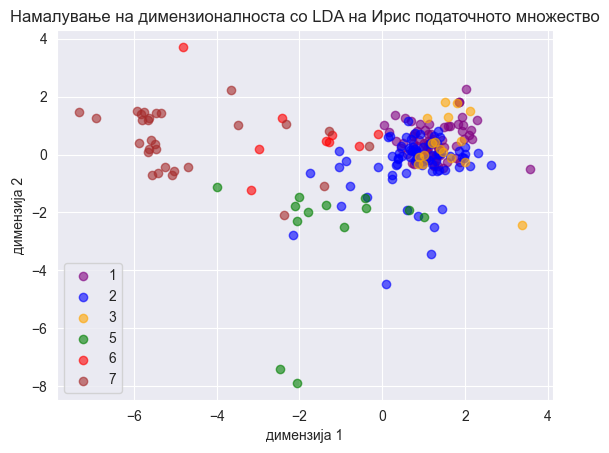

In [20]:
X = df.drop(columns='target')
y = df['target']
colors = ['purple','blue','orange','green','red','brown','pink']

LDA_reduce = LinearDiscriminantAnalysis(n_components=2) # Го поставуваме бројот ан компоненти во новиот простор на 2
LDA_reduce.fit(X, y) # Го фитуваме LDA моделот на податоците X и y
X_reduced = LDA_reduce.transform(X) # Со помош на фитуваниот модел ги трансформираме влезните податоци X во но новите X_LDA

# Сега можеме да го визуелизираме податочното множество на еден дводимензионален график
plt.figure()

for color, i, target_name in zip(colors, [1,2,3,5,6,7], target_names):
    plt.scatter(X_reduced[y == i, 0], X_reduced[y == i, 1], alpha=.6, color=color,
                label=target_name)
plt.legend()
plt.xlabel("димензија 1")
plt.ylabel("димензија 2")
plt.title('Намалување на димензионалноста со LDA на Ирис податочното множество')
plt.show()



In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # Поделба на оригиналното множество на тренинг и тест множества
X_reduced_train, X_reduced_test, y_reduced_train, y_reduced_test = train_test_split(X_reduced, y, test_size=0.3, random_state=42) # Поделба на редуцираното множество на тренинг и тест множества

In [22]:
QDA = QuadraticDiscriminantAnalysis() # иницијализација на моделот
QDA.fit(X_train, y_train); # нагодување на моделот на податоците од тренинг множеството

C:\Users\Sandra\Desktop\python_project\.venv\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\Sandra\Desktop\python_project\.venv\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\Sandra\Desktop\python_project\.venv\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\Sandra\Desktop\python_project\.venv\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full rank. Increasing the value of p

In [23]:
#priorni verojatnodti na sekoja klasa
print("Приорните веројатности на класите се",QDA.priors_)

Приорните веројатности на класите се [0.34228188 0.3557047  0.08724832 0.04697987 0.04026846 0.12751678]


In [24]:
y_pred = QDA.predict(X_test) # предвидување на лабелите од тест множеството со користење на нагодениот модел
QDA_accuracy = accuracy_score(y_test, y_pred) # пресметување на точност на предвидените лабели од тест множеството

print("Точноста на класификацијата со методот QDA во оригиналното Ирис податочно множество е",round(QDA_accuracy,3))

Точноста на класификацијата со методот QDA во оригиналното Ирис податочно множество е 0.062


C:\Users\Sandra\Desktop\python_project\.venv\Lib\site-packages\sklearn\discriminant_analysis.py:1052: RuntimeWarning: divide by zero encountered in power
  X2 = np.dot(Xm, R * (S ** (-0.5)))
C:\Users\Sandra\Desktop\python_project\.venv\Lib\site-packages\sklearn\discriminant_analysis.py:1052: RuntimeWarning: invalid value encountered in multiply
  X2 = np.dot(Xm, R * (S ** (-0.5)))
C:\Users\Sandra\Desktop\python_project\.venv\Lib\site-packages\sklearn\discriminant_analysis.py:1055: RuntimeWarning: divide by zero encountered in log
  u = np.asarray([np.sum(np.log(s)) for s in self.scalings_])
